In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from hmf import MassFunction
from scipy.special import erf

In [5]:

# -----------------------------
# Constants
# -----------------------------
h = 0.7
H0 = h * 100
Om0 = 0.318
sigma8 = 0.8
Mmin = 1e13  # Msun / h
Mmax = 1e15  # Msun / h
area_deg2 = 5000.0

# Fixed redshift bin (selection function = 1)
zmin, zmax = 0.3, 0.5
z_mid = 0.5 * (zmin + zmax)

# -----------------------------
# Cosmology & helper
# -----------------------------
def volume_shell(zmin, zmax, Om0, area_deg2):
    """
    Comoving volume of the redshift shell, restricted to the survey area.
    Returned in (Mpc/h)^3.
    """
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    V = (cosmo.comoving_volume(zmax) - cosmo.comoving_volume(zmin)).to(u.Mpc**3).value
    V /= h**3 # convert to (Mpc/h)^3
    f_sky = area_deg2 / 41253.0
    return V * f_sky 

V_shell = volume_shell(zmin, zmax, Om0, area_deg2)

# -----------------------------
# Mass bins
# -----------------------------
nM = 10
M_edges_logh = np.linspace(np.log10(Mmin), np.log10(Mmax), nM + 1)
M_centres_logh = 0.5 * (M_edges_logh[:-1] + M_edges_logh[1:])
M_centres = 10**M_centres_logh * h  # convert back to Msun

mf = MassFunction(
    z=z_mid,
    cosmo_params={"H0": H0, "Om0": Om0},
    sigma_8=sigma8,
    Mmin=np.log10(Mmin), Mmax=np.log10(Mmax),
    hmf_model="Tinker08",
)

# -----------------------------
# Function to compute "true" counts (no mass scatter)
# -----------------------------
def compute_counts(M_edges_logh):
    """
    Compute expected cluster counts in each mass bin
    for fixed bin edges (true mass bins).
    """
    N_counts = []
    for logMmin, logMmax in zip(M_edges_logh[:-1], M_edges_logh[1:]):
        mf.update(Mmin=logMmin, Mmax=logMmax, z=z_mid)
        if len(mf.m) < 2:
            N_counts.append(0.0)
            continue

        dM = np.gradient(mf.m)
        n_z = np.sum(mf.dndm * dM)    # number density in that bin
        N_counts.append(n_z * V_shell)
    return np.array(N_counts, dtype=float)

# -----------------------------
# Build migration matrix: mass scatter between bins
# -----------------------------
def build_migration_matrix(M_edges_logh, sigma_logM):
    """
    Build P[i, j] = Prob(halo in true bin j is observed in bin i),
    assuming Gaussian scatter in log10(M) with width sigma_logM (dex).

    Columns j are normalised so that sum_i P[i, j] = 1.
    This guarantees number conservation: sum_i N_obs[i] = sum_j N_true[j].
    """
    M_edges_logh = np.asarray(M_edges_logh)
    bin_centres = 0.5 * (M_edges_logh[1:] + M_edges_logh[:-1])
    n_bins = len(bin_centres)

    P = np.zeros((n_bins, n_bins))

    for j in range(n_bins):
        mu = bin_centres[j]
        for i in range(n_bins):
            lo = M_edges_logh[i]
            hi = M_edges_logh[i + 1]

            # Gaussian CDF in log10(M)
            # CDF(x) = 0.5 * [1 + erf((x - mu) / (sqrt(2) * sigma))] 
            # The cumulative of the unit normal distribution is given by above fomular
            cdf_hi = 0.5 * (1.0 + erf((hi - mu) / (np.sqrt(2.0) * sigma_logM)))
            cdf_lo = 0.5 * (1.0 + erf((lo - mu) / (np.sqrt(2.0) * sigma_logM)))
            P[i, j] = cdf_hi - cdf_lo

        # Normalise column j to sum to 1 (numerical safety)
        col_sum = P[:, j].sum()
        if col_sum > 0:
            P[:, j] /= col_sum

    return P

# -----------------------------
# Compute true counts and "observed" counts with scatter
# -----------------------------
sigma_logM = 0.1  # scatter of 0.1 dex in log10(M)

# True counts per *true* mass bin
N_counts_true = compute_counts(M_edges_logh)

# Migration matrix encodes mis-binning due to mass scatter
P = build_migration_matrix(M_edges_logh, sigma_logM)

# Observed counts after haloes migrate between bins
N_counts_scatter = P @ N_counts_true

print("Total true counts   :", N_counts_true.sum())
print("Total with scatter  :", N_counts_scatter.sum())


/global/homes/x/xintang/anaconda3/envs/firecrown_clp/lib/python3.12/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


Total true counts   : 3116490.1372006414
Total with scatter  : 3116490.137200641


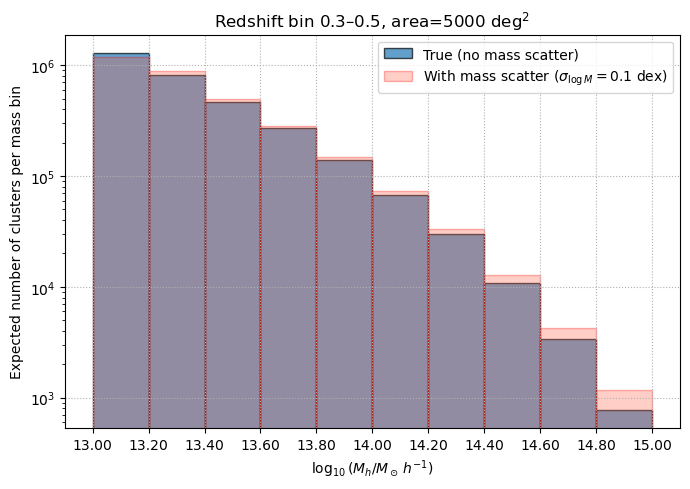

In [6]:
# -----------------------------
# Plot histogram (side-by-side bars)
# -----------------------------
widths_log = np.diff(M_edges_logh)

plt.figure(figsize=(7, 5))

# histogram bars for true counts
plt.bar(
    M_edges_logh[:-1], N_counts_true, width=widths_log,
    align='edge', edgecolor='k', alpha=0.7, label='True (no mass scatter)'
)

# histogram bars for counts after mass scatter / mis-binning
plt.bar(
    M_edges_logh[:-1], N_counts_scatter, width=widths_log,
    align='edge', edgecolor='r', color='tomato', alpha=0.3,
    label=fr'With mass scatter ($\sigma_{{\log M}}={sigma_logM}$ dex)'
)

# x-axis ticks = bin edges in log10(M/h^-1)
plt.xticks(M_edges_logh, [f"{x:.2f}" for x in M_edges_logh])

plt.yscale('log')
plt.xlabel(r'$\log_{10}(M_h / M_\odot\,h^{-1})$')
plt.ylabel(r"Expected number of clusters per mass bin")
plt.title(fr"Redshift bin {zmin:.1f}–{zmax:.1f}, area={area_deg2:.0f} deg$^2$")
plt.legend()
plt.grid(True, ls=":")
plt.tight_layout()
plt.show()
